### CodeChallenge: manipulate regression slopes

1. Write a python function (def) that builds and trains the model and outputs the final predictions and losses.

2. Write a function that creates the data and outputs x, y. x is the same as in the previous video. y = m*x+randn/2. N=50

3. In a parametric experiment, vary the slope from -2 to +2 in 21 steps. Repeat the entire experiment 50 times.

4. Plot the loss and accuracy (correlation of $\hat{y},y$) as a function of the slope.

In [1]:
# import libraries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

### A function that creates and trains the model

In [2]:
def buildAndTrainTheModel(x,y):

    # build the model
    ANNreg = nn.Sequential(
        nn.Linear(1,1), # input layer
        nn.ReLU(), # activation function
        nn.Linear(1,1) # output layer
    )

    # loss and optimizer functions
    lossfun = nn.MSELoss()
    optimizer = torch.optim.SGD(ANNreg.parameters(), lr=0.05)

    # train the model
    numepochs = 500
    losses = torch.zeros(numepochs)

    for epoch in range(numepochs):
        yhat = ANNreg(x) # forward pass
        loss = lossfun(yhat,y) # compute loss

        losses[epoch] = loss.item() # store loss
        
        optimizer.zero_grad() # zero the gradients
        loss.backward() # backward pass
        optimizer.step() # update the weights
    
    # compute model predictions
    predictions = ANNreg(x)

    # output the model parameters
    return predictions, losses

### A function that creates the data

In [3]:
def createTheData(m):
    # create the data
    N = 50
    x = torch.randn(N,1)
    y = m*x + torch.randn(N,1)*0.5
    return x,y

### Test it once

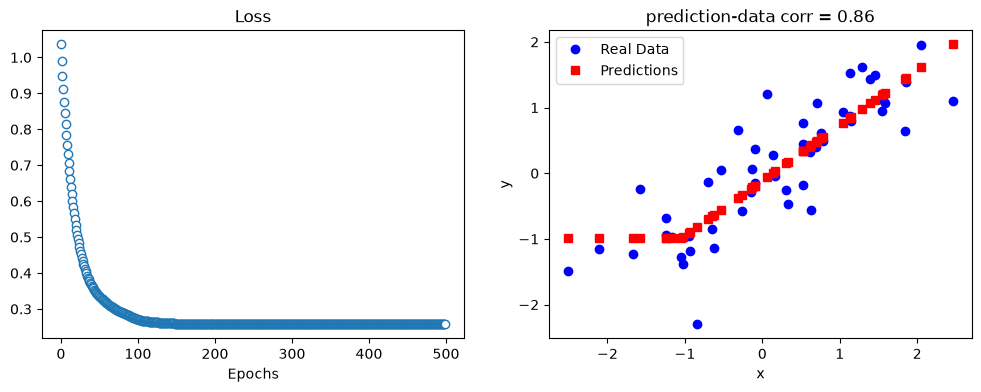

In [4]:
# create a dataset
x,y = createTheData(.8)

#  run the model
yHat, losses = buildAndTrainTheModel(x,y)

fig, ax = plt.subplots(1,2,figsize=(12,4))
# plot the data and predictions
ax[0].plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
ax[0].set_xlabel('Epochs')
ax[0].set_title('Loss')

ax[1].plot(x,y,'bo',label='Real Data')
ax[1].plot(x,yHat.detach(),'rs',label='Predictions')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].set_title(f'prediction-data corr = {np.corrcoef(y.T,yHat.detach().T)[0,1]:.2f}')
ax[1].legend()

plt.show()

### Now for the experiment

In [5]:
# takes 3 mins with 21 slopes and 50 exps

# the slopes to simulate
slopes = np.linspace(-2,2,21)

numExps = 50

# initialize output matrix
results = np.zeros((len(slopes),numExps,2))

for slopei in range(len(slopes)):
    for N in range(numExps):
        # create the data
        x,y = createTheData(slopes[slopei])
        # build and train the model
        yHat, losses = buildAndTrainTheModel(x,y)
        # store the results
        results[slopei,N,0] = losses[-1]
        results[slopei,N,1] = np.corrcoef(y.T,yHat.detach().T)[0,1]

# correlation can be 0 if the model dind't do well. Set nan's s->0
results[np.isnan(results)] = 0

e:\linkedin\Cursos\Udemy\Machine_Learning\udemy-deep-learning-cohen\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\linkedin\Cursos\Udemy\Machine_Learning\udemy-deep-learning-cohen\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


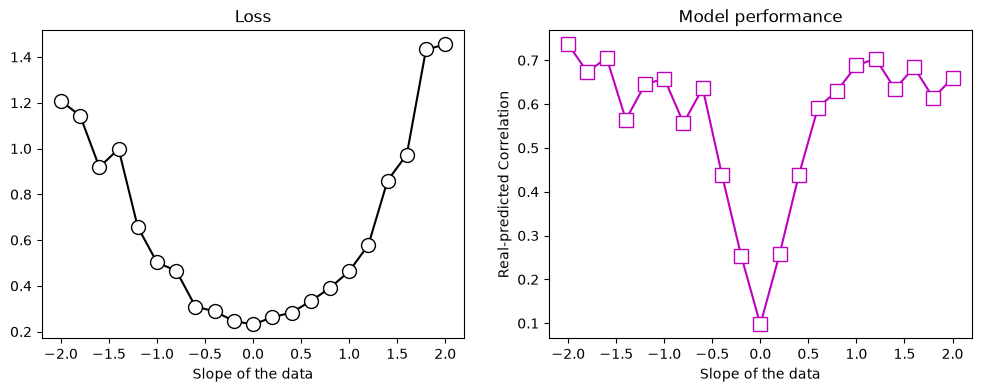

In [6]:
# plot the results!

fig,ax = plt.subplots(1,2,figsize=(12,4))

ax[0].plot(slopes,np.mean(results[:,:,0],axis=1),'ko-',markerfacecolor='w',markersize=10)
ax[0].set_xlabel('Slope of the data')
ax[0].set_title('Loss')

ax[1].plot(slopes,np.mean(results[:,:,1],axis=1),'ms-',markerfacecolor='w',markersize=10)
ax[1].set_xlabel('Slope of the data')
ax[1].set_ylabel('Real-predicted Correlation')
ax[1].set_title('Model performance')

plt.show()